# Mapas Autoorganizados (SOM)


## Entorno de desarrollo

Este trabajo fue realizado en Google Colab utilizando la versión 3.13.15 de Python y las siguientes versiones de librerías externas:
* pandas 2.2.3
* numpy 2.1.3
* matplotlib 3.10.0
* scikit-learn 1.6.1

## Librerías

In [26]:
# Descargar librerías externas
!pip install pandas==2.2.3 numpy==2.1.3 matplotlib==3.10.0 scikit-learn==1.6.1 --quiet

In [6]:
# Importar librerías nativa
import math

# Importar librerías externas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from matplotlib.colors import ListedColormap

## Contexto

Tenemos un dataset con características de seres vivos pero sin etiquetas. La idea es agruparlos por similitud y para eso una red SOM es ideal. Con esto vamos a poder mapear los seres vivos en un plano 2D, logrando que los que tengan atributos más parecidos queden cercanos entre sí de manera natural (por ejemplo, agrupando a los mamíferos en una zona y a las aves en otra).

## Cargar y preparar datos

Cargamos el .csv

In [7]:
archivo = "caracteristicas_animales.csv"
df = pd.read_csv(archivo)

display(df.head())

,HAIR,FEATHERS,EGGS,MILK,AIRBORNE,AQUATIC,PREDATOR,TOOTHED,BACKBONE,BREATHES,VENOMOUS,FINS,LEGS,TAIL,DOMESTIC,CATSIZE
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,4.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,4.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0,1.0


Vemos que todas las columnas tienen valores binarios que representan si el animal tiene o no esa característica. Todas a excepción de la columna LEGS, que contiene cuántas piernas tiene ese ser vivo. Veamos qué valores posibles de LEGS hay en el dataset y cuántos ejemplares hay por cada uno:

In [8]:
conteo_patas = df['LEGS'].value_counts().sort_index()
valores_patas = [float(x) for x in conteo_patas.index]
print("\nCantidad de animales por cada clase de LEGS:")
for patas, cantidad in conteo_patas.items():
    print(f"- {float(patas)} patas: {cantidad} animales")


Cantidad de animales por cada clase de LEGS:
- 0.0 patas: 23 animales
- 2.0 patas: 27 animales
- 4.0 patas: 38 animales
- 5.0 patas: 1 animales
- 6.0 patas: 10 animales
- 8.0 patas: 2 animales


Tenemos la opción de binarizar la columna (One-Hot Encoding), lo que nos dejaría 6 columnas binarias (0_LEGS, 2_LEGS, 4_LEGS, 5_LEGS, 6_LEGS y 8_LEGS) o normalizar esta columna para que los valores vayan de 0 a 1. Tenemos que hacer esto ya que como LEGS toma valores mayores que otros atributos, cuando calculemos el error, va a pesar más que el resto de atributos, y no queremos eso. Optaremos por One-Hot-Encoding en este caso, pero agruparemos 5_LEGS, 6_LEGS y 8_LEGS en una sola variable 5_LEGS_OR_MORE, ya que hay pocos ejemplares de estas características.

In [9]:
mapeo_patas = {
    0.0: '0_LEGS',
    2.0: '2_LEGS',
    4.0: '4_LEGS',
    5.0: '5_LEGS_OR_MORE',
    6.0: '5_LEGS_OR_MORE',
    8.0: '5_LEGS_OR_MORE'
}

df['LEGS'] = df['LEGS'].map(mapeo_patas)
df = pd.get_dummies(df, columns=['LEGS'], prefix='', prefix_sep='', dtype=float)
df.head(10)

,HAIR,FEATHERS,EGGS,MILK,AIRBORNE,AQUATIC,PREDATOR,TOOTHED,BACKBONE,BREATHES,VENOMOUS,FINS,TAIL,DOMESTIC,CATSIZE,0_LEGS,2_LEGS,4_LEGS,5_LEGS_OR_MORE
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
9,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Estructura red SOM

Como nuestro dataset ahora tiene:

In [10]:
cantidad_columnas = df.shape[1]
print(f"El dataset tiene {cantidad_columnas} columnas en total.")

El dataset tiene 19 columnas en total.


Entonces tendremos 19 neuronas de entrada. Y para estimar la cantidad de neuronas de salida, utilizaremos la Regla de Kohonen cuya fórmula es:

$$M \approx 5 \sqrt{N}$$

Siendo:
* M la cantidad de neuronas en la capa de salida.
* N la cantidad de muestras del dataset.

Además, vamos a agregar como condición que M forme un cuadrado, para que las neuronas de salida formen un cuadrado.

In [11]:
# Cálculo de N y M
N = df.shape[0]
print('N = ', N)
M = 5*(np.sqrt(N))
print('M = ', M)

# Determinación de cuántas neuronas tiene el cuadrado con cantidad de casillas más cercanas a M
raiz = math.sqrt(M)
lado = round(raiz)
cuadrado_mas_cercano = lado ** 2
print('Valor de M a utilizar: ',cuadrado_mas_cercano)

N =  101
M =  50.24937810560445
Valor de M a utilizar:  49


Utilizaremos entonces 49 neuronas de salida, conformando una casilla 7x7. Por ende, al tener que conectar 19 neuronas de entrada con 49 neuronas de salida, la matriz de pesos W sería de tamaño 49x19. Pero en SOM, la gracia del algoritmo es que las neuronas forman una cuadrícula, y la noción de cercanía tiene especial relevancia, noción que se perdería armando los pesos en una matriz 49x21 (los pesos de conexión entre las neuronas j e i vecinas podrían quedar super lejos en la matriz). En Redes de Hopfield, esto no importaba mucho ya que no existía esta función de vecindad. Pero acá, para respetarla y facilitar su cálculo más adelante, optaremos por una matriz 3D 7x7x19 (separando la última capa en dos dimensiones y respetando la noción de cercanía que tendrán en la grilla).

## Competición por determinar qué neurona es la ganadora

Aquí definiremos la función que toma un dato de entrada X y determina qué neurona gana la competición a ser la más parecida a ese dato de entrada. Para determinar qué tanto se parece X a una neurona con su peso $w_{j,i}$ utilizaremos la fórmula de distancia euclidiana:

$$D_j = \sqrt{\sum_{i=1}^{n} (X_i - W_{j,i})^2}$$

Donde:
* n: Cantidad total de características de entrada (la longitud de nuestro vector).
* $X_i$: Valor de la característica $i$ en nuestro patrón de entrada (el ser vivo actual).
* $W_{j,i}$: Peso sináptico de la característica $i$ almacenado en la neurona $j$.

Este cálculo lo podemos hacer en una sola operación para obtener la matriz de distancias para un elemento X determinado. Esta será la fórmula que emularemos con código:

$$\begin{bmatrix} D_{1,1} & D_{0,1} & \cdots & D_{1,7} \\ D_{2,1} & D_{2,2} & \cdots & D_{2,7} \\ \vdots & \vdots & \ddots & \vdots \\ D_{7,1} & D_{7,2} & \cdots & D_{7,7} \end{bmatrix} = \sqrt{ \sum_{i=1}^{21} \left( \begin{bmatrix} X_i & \cdots & X_i \\ \vdots & \ddots & \vdots \\ X_i & \cdots & X_i \end{bmatrix}_{7 \times 7} - \begin{bmatrix} W_{0,0,i} & \cdots & W_{0,6,i} \\ \vdots & \ddots & \vdots \\ W_{6,0,i} & \cdots & W_{6,6,i} \end{bmatrix}_{7 \times 7} \right)^2 }$$

Entonces, tendremos 49 valores de salida correspondiente c/u a la distancia de c/neurona a la entrada. La neurona ganadora será aquella con la menor distancia.

In [12]:
# Best Matching Unit (devuelve fila-columna de la neurona ganadora)
def encontrar_bmu(x, W):
    # En realidad x es un vector de 19 elementos, pero con Broadcasting Python lo transforma en 7x7x19 para que coincida con W 7x7x19
    distancias = np.sqrt(np.sum((x - W)**2, axis=2))

    # Buscamos el valor más chico de la matriz y devolvemos su índice
    bmu_idx = np.unravel_index(np.argmin(distancias), distancias.shape)

    return bmu_idx

## Actualización de pesos

Luego de determinar la neurona ganadora, tenemos que actualizar los pesos de cada conexión. Esto lo haremos siguiendo esta fórmula:

$$NUEVO \ W = W + \eta \cdot H_{g} \cdot [X - W]$$

Siendo:
* η: Tasa de aprendizaje.
* X: Matriz 7x7 que contiene en cada elemento las 19 características del ser vivo X (sería en realidad 7x7x19).
* W: Matriz 7x7x19 de pesos.
* $H_g$: Función de vecindad que determina qué tan cercana está la neurona g (ganadora) de la neurona a actualizar (la neurona cuyo peso estamos actualizando). A mayor valor, más cercanas.

Como función de vecindad $h_{g,j}$ utilizaremos la función Gaussiana:

$$h_{g,(r,c)} = e^{-\frac{||pos_g - pos_{(r,c)}||^2}{2 \sigma^2}}$$

Donde:
* g: Neurona ganadora.
* (r,c): Neurona ubicada en la posición (r,c) en la grilla de salida.
* $||pos_g - pos_{(r,c)}||$: Distancia Euclidiana topológica entre g y (r,c).
* $\sigma$: Constante correspondiente al radio de vecindad en la iteración actual (el ancho de la campana de Gauss).

Por lo que la matriz $H_g$ se calculará de la siguiente forma:


$$H_g = \begin{bmatrix} h_{g,(1,1)} & h_{g,(1,2)} & \cdots & h_{g,(1,7)} \\ h_{g,(2,1)} & h_{g,(2,2)} & \cdots & h_{g,(2,7)} \\ \vdots & \vdots & \ddots & \vdots \\ h_{g,(7,1)} & h_{g,(7,2)} & \cdots & h_{g,(7,7)} \end{bmatrix}$$

Donde cada elemento $h_{g,(r,c)}$ se calcularía con la fórmula ya mencionada anteriormente. Aún así, tenemos que recordar que la fórmula de actualización de pesos era:

$$NUEVO \ W = W + \eta \cdot H_{g} \cdot [X - W]$$

Para poder multiplicar (X-W) por $H_g$, el broadcasting de Python transformaría la matriz $H_g$ de 7x7 a 7x7x19, y ahí si nos dan las dimensiones para hacer una multiplicación elemento a elemento (no es la multiplicación normal de matrices).

In [13]:
# Función para calcular Hg
def funcion_vecindad_gaussiana(bmu_idx, filas, columnas, sigma):
    r, c = np.indices((filas, columnas))
    distancia_cuadrada = (r - bmu_idx[0])**2 + (c - bmu_idx[1])**2   # Distancia euclidiana entre g y (r,c)
    H_g = np.exp(-distancia_cuadrada / (2 * (sigma**2)))             # Fórmula de campana Gaussiana

    return H_g

def actualizar_pesos(W, x, bmu_idx, sigma, eta):
    filas, columnas, _ = W.shape                                               # Obtenemos las dimensiones de la grilla a partir de W (en este caso, seria 7x7)
    H_g = funcion_vecindad_gaussiana(bmu_idx, filas, columnas, sigma)          # Calculamos Hg
    H_g_expandida = H_g[:, :, np.newaxis]                                      # Expandimos Hg de 7x7 a 7x7x1 para habilitar el broadcasting (se expandirá a 7x7x19)
    W_nuevo = W + eta * H_g_expandida * (x - W)

    return W_nuevo

## Actualización de constantes η y σ

Al principio, en las primeras épocas de entrenamiento, tanto la tasa de aprendizaje η como el radio η σ de la función Gaussiana deberían ser altos, ya que los pesos aún no están nada ajustados. Pero a medida que avanzamos en el entrenamiento, deberían hacerse más chicos. Para actualizar ambos parámetros, utilizaremos estas fórmulas:

$$\eta(t) = \eta_0 \cdot e^{-\frac{t}{T}}$$

$$\sigma(t) = \sigma_0 \cdot e^{-\frac{t}{T}}$$

Donde:
* t: Es la iteración o época actual.
* T: Es la constante de tiempo (generalmente asociada al número total de iteraciones planeadas).
* $\eta_0$: Es la tasa de aprendizaje inicial (en $t=0$).
* $\sigma_0$: Es el radio de vecindad inicial (en $t=0$).

In [14]:
def actualizar_hiperparametros(t, T, eta_0, sigma_0):
    factor_decaimiento = np.exp(-t / T)
    eta_t = eta_0 * factor_decaimiento
    sigma_t = sigma_0 * factor_decaimiento

    return eta_t, sigma_t

## Entrenamiento del SOM

Ahora solo queda entrenar la red SOM con los datos del dataset. Cada época de entrenamiento utilizaremos todos los datos para entrenarla, ya que tenemos relativamente pocos datos.

In [15]:
def entrenar_som(X, W, epocas, eta_0, sigma_0):
    filas, columnas, _ = W.shape
    num_muestras = X.shape[0]

    for epoca in range(epocas):
        eta, sigma = actualizar_hiperparametros(epoca, epocas, eta_0, sigma_0) # Actualizo tasa de aprendizaje y radio
        indices = np.random.permutation(num_muestras)                          # Ordenar aleatoriamente los seres vivos para el entrenamiento en esta época

        for idx in indices:
            x = X[idx]
            bmu_idx = encontrar_bmu(x, W)                                     # Competición
            W = actualizar_pesos(W, x, bmu_idx, sigma, eta)                   # Actualizar W

    return W

In [16]:
np.random.seed(42)  # Para obtener siempre el mismo mapa
X = df.values       # Paso el dataframe a la variable X

# Inicialización de hiperparámetros y pesos para el entrenamiento
filas, columnas, D = 7, 7, X.shape[1]    # Estas dimensiones las utilizaremos también en otras secciones del notebook
W = np.random.rand(filas, columnas, D)
epocas = 500
eta_0 = 0.1
sigma_0 = max(W.shape[0], W.shape[1]) / 2.0   # Inicialización estándar del radio

# Ejecución del entrenamiento con la función integrada
W_entrenada = entrenar_som(X, W, epocas, eta_0, sigma_0)

## SOM resultante del entrenamiento

### Agrupamiento y etiquetado de zonas del SOM

Aplicaremos algún método de agrupamiento sobre las neuronas de la capa de salida, específicamente sobre sus matrices W, para poder dividir luego el mapa SOM en clusters y visualmente clasificar los datos mucho mejor, hasta etiquetarlos.

Como método de clustering, utilizaremos DBSCAN. A diferencia de K-Means, este método no requiere imponer una cantidad de grupos de antemano. Como este no es un notebook sobre métodos de clustering, pasaremos al código que aplica este método sin meternos mucho en teoría de cómo funciona. Le pedimos a DBSCAN que solo forme clusters de mínimo 3 elementos, y así nos quedan clasificados los elementos (se muestra el número de cluster al que pertenece cada elemento, y -1 para las neuronas que son consideradas "ruido", o más bien los elementos que en ella caigan serán ruido).

In [17]:
# Aplanamos la matriz de pesos W la forma (N_neuronas, D), siendo D la cantidad de características de cada ser vivo
W_plano = W_entrenada.reshape(-1, D)

# Aplicamos DBSCAN
dbscan = DBSCAN(eps=0.47, min_samples=3)
etiquetas_dbscan = dbscan.fit_predict(W_plano)

# Armamos la grilla etiquetada con el número de cluster al que pertenece cada elemento
mapa_clusters_dbscan = etiquetas_dbscan.reshape(filas, columnas)

print("Mapa de clústeres asignados por DBSCAN (-1 indica frontera/ruido):\n")
print(mapa_clusters_dbscan)

Mapa de clústeres asignados por DBSCAN (-1 indica frontera/ruido):

[[ 0  0  0  0 -1 -1 -1]
 [ 0  0  0  0 -1 -1 -1]
 [ 0  0  0 -1  2  1  1]
 [-1 -1 -1  2  2  1  1]
 [-1 -1  3 -1  2 -1 -1]
 [ 3  3  3  3 -1  4  4]
 [ 3  3  3  3 -1  4  4]]


### Matriz U

Para que se vea todo mejor, traspolaremos esta clasificación de 5 clusters a la matriz U. La matriz es un heatmap que muestra qué tan distantes están las neuronas de su vecindad. Mostrará colores oscuros cuando las neuronas estén alejadas en el espacio de características de sus vecinas, y colores claros cuando estén cercanas. Generalmente, las zonas de colores claros deberían coincidir con las fronteras entre clusters, así que veamos si esto es cierto.

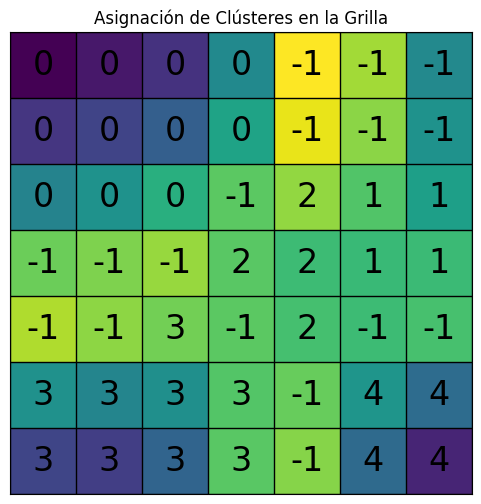

In [18]:
# Definimos la matriz U
u_matrix = np.zeros((filas, columnas))
for i in range(filas):
    for j in range(columnas):
        vecindario = W_entrenada[max(0, i-1):i+2, max(0, j-1):j+2]
        distancias = np.linalg.norm(vecindario - W_entrenada[i, j], axis=-1)
        u_matrix[i, j] = distancias[distancias > 0].mean()

# Visualización de la matriz U
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(u_matrix, cmap='viridis')
ax.set_ylim(filas - 0.5, -0.5)
ax.set_xlim(-0.5, columnas - 0.5)
ax.set_xticks(np.arange(-0.5, columnas, 1))
ax.set_yticks(np.arange(-0.5, filas, 1))
ax.grid(color='black', linewidth=1)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(length=0)

# Le agregamos el número de cluster a cada casilla
for (i, j), cluster_id in np.ndenumerate(mapa_clusters_dbscan):
    ax.text(j, i, str(cluster_id), ha='center', va='center', fontsize=24, color='black')

plt.title('Asignación de Clústeres en la Grilla')
plt.show()

Las zonas más oscuras claramente coinciden con clusters, mientras que las zonas más amarillas coinciden mayormente con fronteras y neuronas no asignadas a ningún cluster. El clustering hecho con DBSCAN mostró ser muy bueno.

### Etiquetado

Solo queda etiquetar estas zonas dependiendo de las características que presentan los seres vivos que suelen caer en estas neuronas.

In [19]:
nombres_columnas = df.columns.tolist()
clusters_unicos = np.unique(mapa_clusters_dbscan)

print("PERFIL DE CADA CLUSTER")
for cluster_id in clusters_unicos:
    # Ignoramos el -1
    if cluster_id == -1:
        continue

    # Filtramos las neuronas de ese cluster
    mascara = (mapa_clusters_dbscan == cluster_id)
    pesos_del_cluster = W_entrenada[mascara]

    perfil_promedio = pesos_del_cluster.mean(axis=0) # Calculamos el promedio de esa característica

    print(f"\nClúster {cluster_id}:")

    # Imprimimos el nombre de la característica junto al valor promedio en ese cluster
    for nombre, valor in zip(nombres_columnas, perfil_promedio):
        print(f"  - {nombre}: {valor:.4f}")

PERFIL DE CADA CLUSTER

Clúster 0:
  - HAIR: 0.9367
  - FEATHERS: 0.0074
  - EGGS: 0.0847
  - MILK: 0.9335
  - AIRBORNE: 0.0369
  - AQUATIC: 0.1090
  - PREDATOR: 0.5128
  - TOOTHED: 0.9422
  - BACKBONE: 0.9836
  - BREATHES: 0.9971
  - VENOMOUS: 0.0122
  - FINS: 0.0404
  - TAIL: 0.8281
  - DOMESTIC: 0.1902
  - CATSIZE: 0.7644
  - 0_LEGS: 0.0285
  - 2_LEGS: 0.1147
  - 4_LEGS: 0.8430
  - 5_LEGS_OR_MORE: 0.0138

Clúster 1:
  - HAIR: 0.0955
  - FEATHERS: 0.0029
  - EGGS: 0.9100
  - MILK: 0.0471
  - AIRBORNE: 0.0816
  - AQUATIC: 0.6245
  - PREDATOR: 0.7286
  - TOOTHED: 0.2784
  - BACKBONE: 0.3090
  - BREATHES: 0.4889
  - VENOMOUS: 0.1991
  - FINS: 0.0458
  - TAIL: 0.2260
  - DOMESTIC: 0.0331
  - CATSIZE: 0.1296
  - 0_LEGS: 0.2917
  - 2_LEGS: 0.0030
  - 4_LEGS: 0.2921
  - 5_LEGS_OR_MORE: 0.4132

Clúster 2:
  - HAIR: 0.1778
  - FEATHERS: 0.0748
  - EGGS: 0.8301
  - MILK: 0.1808
  - AIRBORNE: 0.0491
  - AQUATIC: 0.5645
  - PREDATOR: 0.7020
  - TOOTHED: 0.6261
  - BACKBONE: 0.8229
  - BREATHES: 

Devuelta, el propósito de este notebook no es aprender a etiquetar, solo aprender cómo funcionan las redes SOM. Por eso, realizamos el etiquetado de cada clúster con IA, quedándonos etiquetados de la siguiente manera:
* Clúster 0: Mamíferos (Terrestres).
* Clúster 1: Invertebrados.
* Clúster 2: Reptiles y Anfibios.
* Clúster 3: Aves.
* Clúster 4: Peces.

### SOM con etiquetado añadido

Añadimos las etiquetas y les asignamos un color para ver cómo se ven en el mapa

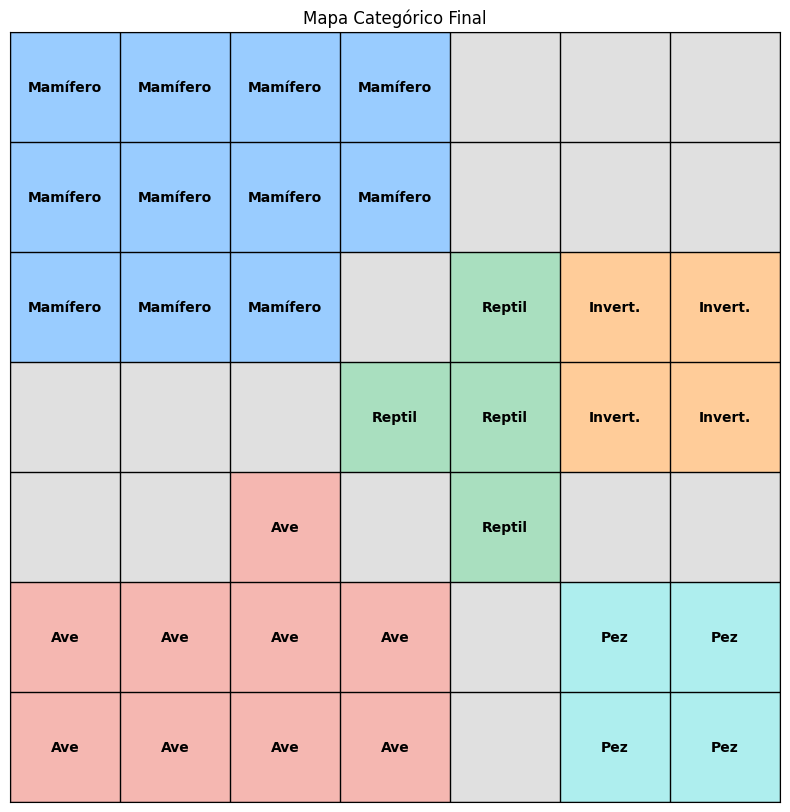

In [20]:
# Nombres de cada cluster
nombres_clusters = {
    0: "Mamífero",
    1: "Invert.",
    2: "Reptil",
    3: "Ave",
    4: "Pez",
    -1: ""
}

# Colores de cada cluster
colores = [
    '#E0E0E0', # -1: Gris claro (Frontera)
    '#99CCFF', #  0: Azul claro (Mamíferos)
    '#FFCC99', #  1: Naranja claro (Invertebrados)
    '#A9DFBF', #  2: Verde claro (Reptiles)
    '#F5B7B1', #  3: Rojo claro (Aves)
    '#AEEEEE'  #  4: Cian claro (Peces)
]
cmap_personalizado = ListedColormap(colores)
fig, ax = plt.subplots(figsize=(10, 10))

# Visualización
ax.imshow(mapa_clusters_dbscan, cmap=cmap_personalizado, vmin=-1, vmax=4)
ax.set_ylim(filas - 0.5, -0.5)
ax.set_xlim(-0.5, columnas - 0.5)
ax.set_xticks(np.arange(-0.5, columnas, 1))
ax.set_yticks(np.arange(-0.5, filas, 1))
ax.grid(color='black', linewidth=1)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(length=0)

for (i, j), cluster_id in np.ndenumerate(mapa_clusters_dbscan):
    if cluster_id != -1:
        texto = nombres_clusters.get(cluster_id, str(cluster_id))
        ax.text(j, i, texto, ha='center', va='center', fontsize=10, color='black', fontweight='bold')

plt.title('Mapa Categórico Final')
plt.show()

Y también creamos la función de clasificar un nuevo ser vivo, añadiendole la etiqueta:

In [21]:
def clasificar_nuevo_animal(nuevo_vector, W, mapa_clusters, nombres_clusters):
    bmu_idx = encontrar_bmu(nuevo_vector, W)                                     # Competencia
    cluster_asignado = mapa_clusters[bmu_idx]                                    # Buscamos el número de cluster de la neurona ganadora
    nombre_categoria = nombres_clusters.get(cluster_asignado, "Desconocido")     # Traducimos el número al nombre semántico

    return nombre_categoria, bmu_idx

### Ejemplos de funcionamiento

Entonces, esta red la podemos utilizar tanto para saber la categoría de uno de los datos de nuestro dataset como para clasificar nuevos datos. Probemos primero como funciona con un dato nuevo: Un pingüino.

--- PRUEBA DE INFERENCIA ---
El animal ingresado activó la neurona ganadora BMU en la posición: (5,2)
Según lo aprendido por el mapa SOM, el animal pertenece a la categoría: Ave



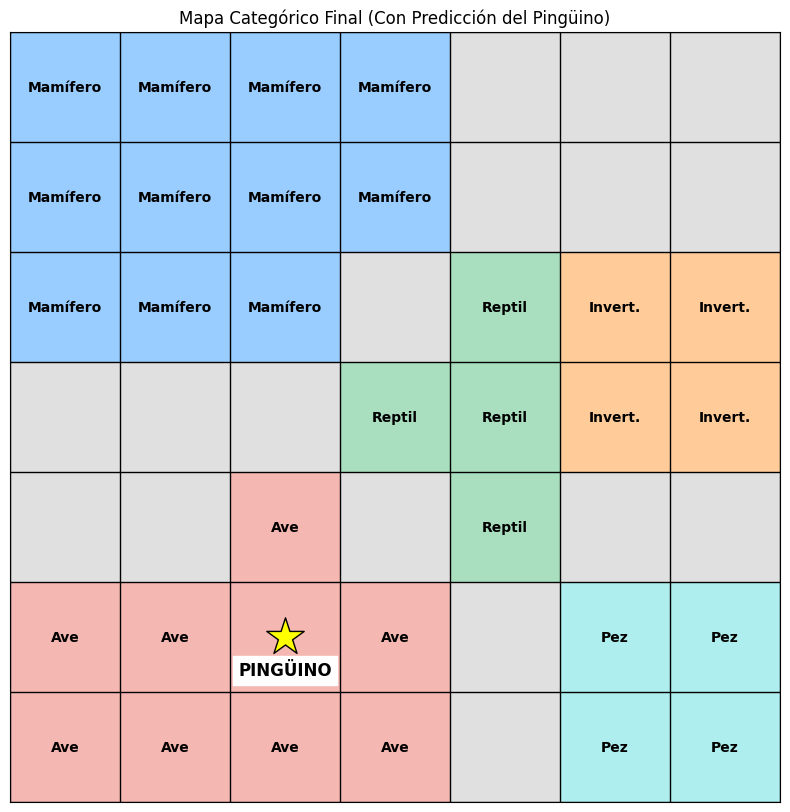

In [22]:
# El vector de nuestro ser vivo de prueba: El pingüino
vector_pinguino = np.array([
    0.0,  # HAIR
    1.0,  # FEATHERS
    1.0,  # EGGS
    0.0,  # MILK
    0.0,  # AIRBORNE
    1.0,  # AQUATIC
    1.0,  # PREDATOR
    0.0,  # TOOTHED
    1.0,  # BACKBONE
    1.0,  # BREATHES
    0.0,  # VENOMOUS
    0.0,  # FINS
    1.0,  # TAIL
    0.0,  # DOMESTIC
    1.0,  # CATSIZE
    0.0,  # 0_LEGS
    1.0,  # 2_LEGS
    0.0,  # 4_LEGS
    0.0   # 5_LEGS_OR_MORE
])

categoria_predicha, bmu = clasificar_nuevo_animal(vector_pinguino, W_entrenada, mapa_clusters_dbscan, nombres_clusters)

print("--- PRUEBA DE INFERENCIA ---")
print(f"El animal ingresado activó la neurona ganadora BMU en la posición: ({bmu[0]},{bmu[1]})")

print(f"Según lo aprendido por el mapa SOM, el animal pertenece a la categoría: {categoria_predicha}\n")
fig, ax = plt.subplots(figsize=(10, 10))

# Visualización de la red SOM etiquetada + el pinguino en la neurona ganadora
ax.imshow(mapa_clusters_dbscan, cmap=cmap_personalizado, vmin=-1, vmax=4)
ax.set_ylim(filas - 0.5, -0.5)
ax.set_xlim(-0.5, columnas - 0.5)
ax.set_xticks(np.arange(-0.5, columnas, 1))
ax.set_yticks(np.arange(-0.5, filas, 1))
ax.grid(color='black', linewidth=1)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(length=0)
for (i, j), cluster_id in np.ndenumerate(mapa_clusters_dbscan):

    if i == bmu[0] and j == bmu[1]:
        ax.scatter(j, i, marker='*', s=800, color='yellow', edgecolors='black', zorder=5)
        ax.text(j, i + 0.3, "PINGÜINO", ha='center', va='center', fontsize=12,
                fontweight='bold', backgroundcolor='white', zorder=6)
    elif cluster_id != -1:
        # Agregamos el nombre del cluster en cada casilla
        texto = nombres_clusters.get(cluster_id, str(cluster_id))
        ax.text(j, i, texto, ha='center', va='center', fontsize=10,
                color='black', fontweight='bold')

plt.title('Mapa Categórico Final (Con Predicción del Pingüino)')
plt.show()

Además, podemos tomar algún X de la base de datos y clasificarlo también. Clasificaremos el elemento 10 del dataset:

--- PRUEBA CON ANIMAL DEL DATASET ---
La neurona ganadora BMU está en la posición: (1, 0)
El SOM lo clasificó en la categoría: Mamífero



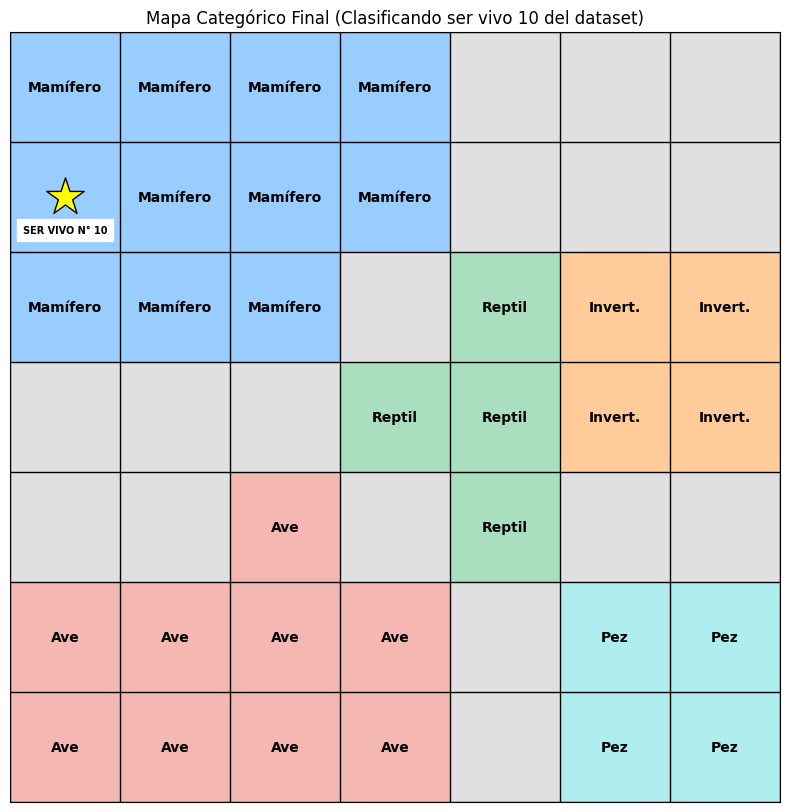

In [23]:
indice_elegido = 10
vector_dataset = df.iloc[indice_elegido].values
categoria_predicha, bmu = clasificar_nuevo_animal(vector_dataset, W_entrenada, mapa_clusters_dbscan, nombres_clusters)

print("--- PRUEBA CON ANIMAL DEL DATASET ---")
print(f"La neurona ganadora BMU está en la posición: ({bmu[0]}, {bmu[1]})")
print(f"El SOM lo clasificó en la categoría: {categoria_predicha}\n")

# Visualización de la red SOM etiquetada + la neurona ganadora
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mapa_clusters_dbscan, cmap=cmap_personalizado, vmin=-1, vmax=4)
ax.set_ylim(filas - 0.5, -0.5)
ax.set_xlim(-0.5, columnas - 0.5)
ax.set_xticks(np.arange(-0.5, columnas, 1))
ax.set_yticks(np.arange(-0.5, filas, 1))
ax.grid(color='black', linewidth=1)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(length=0)

for (i, j), cluster_id in np.ndenumerate(mapa_clusters_dbscan):
    if i == bmu[0] and j == bmu[1]:
        ax.scatter(j, i, marker='*', s=800, color='yellow', edgecolors='black', zorder=5)
        ax.text(j, i + 0.3, f"SER VIVO N° {indice_elegido}", ha='center', va='center', fontsize=7,
                fontweight='bold', backgroundcolor='white', zorder=6)

    elif cluster_id != -1:
        texto = nombres_clusters.get(cluster_id, str(cluster_id))
        ax.text(j, i, texto, ha='center', va='center', fontsize=10,
                color='black', fontweight='bold')

plt.title(f'Mapa Categórico Final (Clasificando ser vivo {indice_elegido} del dataset)')
plt.show()

Nos da que es mamífero, veamos si tiene sentido que lo sea observando las características de dicho ser vivo:

In [24]:
indice_elegido = 10
ser_vivo = df.iloc[indice_elegido]

print(f"CARACTERÍSTICAS DEL ANIMAL (N° {indice_elegido})")
rasgos_positivos = ser_vivo[ser_vivo == 1.0].index.tolist()
for rasgo in rasgos_positivos:
    print(f"✔️ {rasgo}")

CARACTERÍSTICAS DEL ANIMAL (N° 10)
✔️ HAIR
✔️ MILK
✔️ PREDATOR
✔️ TOOTHED
✔️ BACKBONE
✔️ BREATHES
✔️ CATSIZE
✔️ 4_LEGS


Biológicamente, tener pelo (HAIR) y producir leche (MILK) son los dos rasgos definitivos y exclusivos de esta clase. El resto de las características (es vertebrado, respira aire, tiene 4 patas y dientes) terminan de confirmar que es un mamífero terrestre típico (como un felino, un lobo o un oso).

## Créditos

* Dataset de características de animales: Datos derivados del Zoo dataset, UCI Machine Learning Repository (donante: Richard S. Forsyth). Disponible en https://archive.ics.uci.edu/dataset/111/zoo bajo licencia CC BY 4.0.